In [1]:
import numpy as np
import matplotlib.pyplot as plt
import LAMINAR
from sklearn.datasets import make_moons, make_circles, make_blobs
import torch

#https://www.geeksforgeeks.org/k-means-clustering-introduction/

from torch.profiler import profile, record_function, ProfilerActivity

In [2]:
colour = {
    'g': np.array([0, 158, 115])/256,
    'b': np.array([0, 114, 178])/256,
    'lb': np.array([86, 180, 233])/256,
    'r': np.array([213, 94, 0])/256,
    'o': np.array([230, 159, 0])/256,
    'y': np.array([240, 228, 66])/256,
    'p': np.array([204, 121, 167])/256,
    }

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

## Make Data

In [4]:
def moons():
    X, y = make_moons(n_samples=1000, noise=0.1)
    X = (X-X.mean(axis=0))/X.std(axis=0)

    data = torch.tensor(X, dtype=torch.float32)
    labels = torch.tensor(y, dtype=torch.float32)

    # shuffle data and labels
    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]
    return data.to(device), labels.to(device)

def circles():
    X, y = make_circles(n_samples=1000, noise=0.05, factor=0.65)
    X = (X-X.mean(axis=0))/X.std(axis=0)

    data = torch.tensor(X, dtype=torch.float32)
    labels = torch.tensor(y, dtype=torch.float32)

    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]
    return data.to(device), labels.to(device)

def streched_gaussians():
    X, Labels = make_blobs(n_samples=1000, random_state=170)
    transformation = [[0.6, -0.6], [-0.4, 0.8]]
    X_aniso = np.dot(X, transformation)

    data = (X_aniso - X_aniso.mean(axis=0)) / X_aniso.std(axis=0)
    data = torch.tensor(data, dtype=torch.float32)
    labels = torch.tensor(Labels, dtype=torch.float32)

    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]
    return data.to(device), labels.to(device)

def combined_structure():
    data, labels = make_moons(n_samples=500, noise=0.1)

    # take the upper moons as data1
    data1 = data[labels == 0]
    data1[:, 0] = data1[:, 0] * 2

    # lower moon as data2
    data2 = data[labels == 1]

    # move and scale lower moon
    data2 = (data2 + np.array([-1, 1.5])) * -3

    # gaussian distribution at 0 0
    data3 = np.random.normal(loc=np.array([0, -1]), scale=0.65, size=(500, 2))

    labels = np.zeros(1000, dtype=int)
    labels[250:] = 1
    labels[500:] = 2
    
    data = np.vstack([data1, data2, data3])

    # standardize
    data = (data - data.mean(axis=0)) / data.std(axis=0)

    data = torch.tensor(data, dtype=torch.float32)
    labels = torch.tensor(labels, dtype=torch.float32)

    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]

    return data.to(device), labels.to(device)

def four_gaussians():
    n = 1000
    n_per_gaussian = n // 4

    g1 = np.random.normal(size=(n_per_gaussian, 2))
    g2 = np.random.normal(size=(n_per_gaussian, 2))
    g3 = np.random.normal(size=(n_per_gaussian, 2))
    g4 = np.random.normal(size=(n_per_gaussian, 2))

    g1[:, 0] -= 1.5
    g1[:, 1] -= 0.25

    g1 *= 0.75

    g2[:, 0] += 3
    g2[:, 1] += 3

    g2 *= 0.5

    g3[:, 0] += 3
    g3[:, 1] -= 1.5

    g3 *= 0.25

    g4[:, 0] -= 1.5
    g4[:, 1] += 3

    g4[:, 0] *= 0.15

    data = np.vstack([g1, g2, g3, g4])
    data = (data - data.mean(axis=0)) / data.std(axis=0)

    labels = np.zeros(n, dtype=int)
    labels[n_per_gaussian:] = 1
    labels[2*n_per_gaussian:] = 2
    labels[3*n_per_gaussian:] = 3

    data = torch.tensor(data, dtype=torch.float32)
    labels = torch.tensor(labels, dtype=torch.float32)

    idx = torch.randperm(data.size(0))
    data = data[idx]
    labels = labels[idx]

    return data.to(device), labels.to(device)

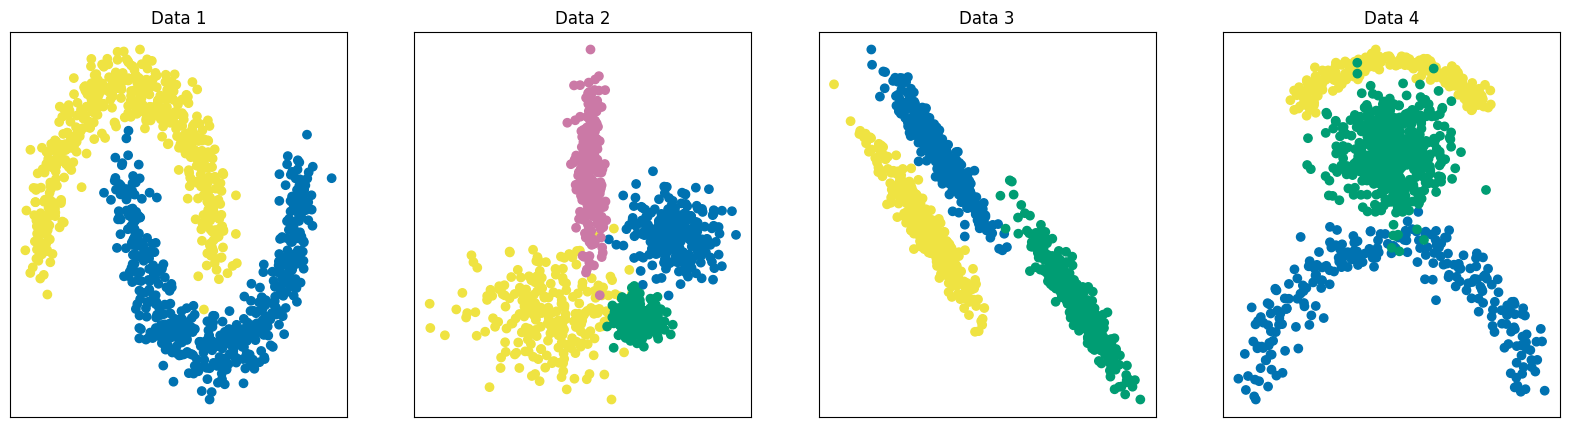

In [5]:
data1 = moons()
data2 = four_gaussians()
data3 = streched_gaussians()
data4 = combined_structure()

fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for i, (data, labels) in enumerate([data1, data2, data3, data4]):
    axs[i].scatter(data[labels == 0, 0], data[labels == 0, 1], c=[colour['y'] for _ in range(data[labels == 0].shape[0])])
    axs[i].scatter(data[labels == 1, 0], data[labels == 1, 1], c=[colour['b'] for _ in range(data[labels == 1].shape[0])])
    axs[i].scatter(data[labels == 2, 0], data[labels == 2, 1], c=[colour['g'] for _ in range(data[labels == 2].shape[0])])
    axs[i].scatter(data[labels == 3, 0], data[labels == 3, 1], c=[colour['p'] for _ in range(data[labels == 3].shape[0])])
    axs[i].scatter(data[labels == 4, 0], data[labels == 4, 1], c=[colour['lb'] for _ in range(data[labels == 4].shape[0])])
    axs[i].set_title(f"Data {i+1}")
    axs[i].set_xticks([])
    axs[i].set_yticks([])

plt.show()

## Euclidean Clustering

In [6]:
def distance_euclidean(x, y):
    return torch.sqrt(torch.sum((x-y)**2))

In [7]:
def k_means(data, k, distance, epochs=1000):
    n = data.shape[0]
    m = data.shape[1]
    centroids = np.random.rand(k, m)
    for _ in range(epochs):
        clusters = [[] for _ in range(k)]
        for i in range(n):
            distances = [distance(data[i], centroids[j]) for j in range(k)]
            clusters[np.argmin(distances)].append(i)
        for j in range(k):
            if len(clusters[j]) > 0:
                centroids[j] = torch.mean(data[clusters[j]], axis=0) # np.mean assumes euclidean geometry. LAMINAR is not applicable here
    return centroids, clusters

In [8]:
def transform_labels(labels):
    # labels is a list of lists with inices of points in the same cluster
    # transform into an array with the length of the higherst index found and assignt each index the cluster it is in
    n = max([max(cluster) for cluster in labels]) + 1
    transformed = np.zeros(n)
    for i, cluster in enumerate(labels):
        transformed[cluster] = i
    return transformed

In [9]:
centroids1_euc, labels1_euc = k_means(data1[0], 2, distance_euclidean, 15)
labels1_euc = transform_labels(labels1_euc)
centroids2_euc, labels2_euc = k_means(data2[0], 4, distance_euclidean, 15)
labels2_euc = transform_labels(labels2_euc)
centroids3_euc, labels3_euc = k_means(data3[0], 3, distance_euclidean, 15)
labels3_euc = transform_labels(labels3_euc)
centroids4_euc, labels4_euc = k_means(data4[0], 3, distance_euclidean, 15)
labels4_euc = transform_labels(labels4_euc)

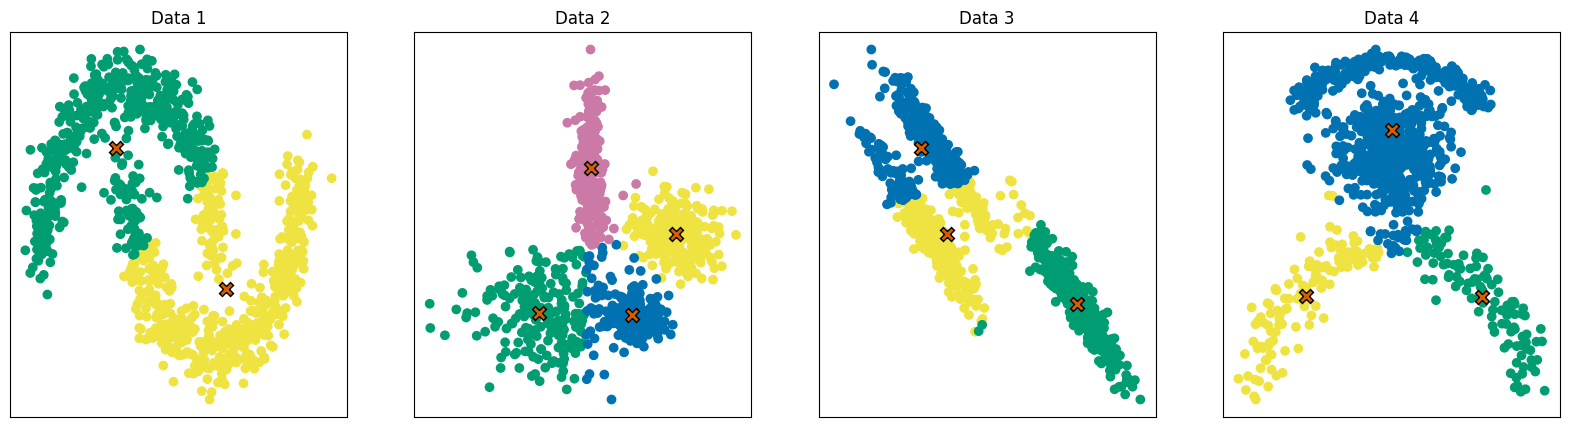

In [10]:
# plot clustering with euclidean
fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for i, (data, labels, medoids) in enumerate([(data1[0], labels1_euc, centroids1_euc), (data2[0], labels2_euc, centroids2_euc), (data3[0], labels3_euc, centroids3_euc), (data4[0], labels4_euc, centroids4_euc)]):
    axs[i].scatter(data[labels == 0, 0], data[labels == 0, 1], c=[colour['y'] for _ in range(data[labels == 0].shape[0])])
    axs[i].scatter(data[labels == 1, 0], data[labels == 1, 1], c=[colour['g'] for _ in range(data[labels == 1].shape[0])])
    axs[i].scatter(data[labels == 2, 0], data[labels == 2, 1], c=[colour['b'] for _ in range(data[labels == 2].shape[0])])
    axs[i].scatter(data[labels == 3, 0], data[labels == 3, 1], c=[colour['p'] for _ in range(data[labels == 3].shape[0])])
    axs[i].scatter(data[labels == 4, 0], data[labels == 4, 1], c=[colour['lb'] for _ in range(data[labels == 4].shape[0])])

    axs[i].scatter(medoids[:, 0], medoids[:, 1], c='black', marker='x', s=75, linewidths=4)
    axs[i].scatter(medoids[:, 0], medoids[:, 1], c=[colour['r']], marker='x', s=50, linewidths=2)
    axs[i].set_title(f"Data {i+1}")
    axs[i].set_xticks([])
    axs[i].set_yticks([])

plt.show()

## LAMINAR Clustering

In [11]:
LAM1 = LAMINAR.LAMINAR(data1[0], drop_freq=9999, epochs=1000, save_distance_matrix=False)

Iteration 0 | Train Loss: 1207.7882080078125 | Validation Loss: 1656.3662109375
Iteration 99 | Train Loss: 274.3944396972656 | Validation Loss: 280.2026672363281
Iteration 199 | Train Loss: 248.3384552001953 | Validation Loss: 253.15774536132812
Iteration 299 | Train Loss: 244.03326416015625 | Validation Loss: 247.4045867919922
Iteration 399 | Train Loss: 223.0210418701172 | Validation Loss: 227.94754028320312
Iteration 499 | Train Loss: 222.80775451660156 | Validation Loss: 228.37557983398438
Iteration 599 | Train Loss: 212.07379150390625 | Validation Loss: 223.80706787109375
Iteration 699 | Train Loss: 214.37164306640625 | Validation Loss: 224.2846221923828
Iteration 799 | Train Loss: 212.06202697753906 | Validation Loss: 218.45108032226562
Iteration 899 | Train Loss: 207.15579223632812 | Validation Loss: 213.225341796875
Iteration 999 | Train Loss: 203.3594970703125 | Validation Loss: 209.79881286621094


In [12]:
LAM2 = LAMINAR.LAMINAR(data2[0], drop_freq=9999, epochs=1000, save_distance_matrix=False)

Iteration 0 | Train Loss: 1344.60888671875 | Validation Loss: 2077.55810546875
Iteration 99 | Train Loss: 265.03155517578125 | Validation Loss: 257.0855712890625
Iteration 199 | Train Loss: 216.28482055664062 | Validation Loss: 206.92544555664062
Iteration 299 | Train Loss: 201.10421752929688 | Validation Loss: 187.7267608642578
Iteration 399 | Train Loss: 199.75054931640625 | Validation Loss: 186.82342529296875
Iteration 499 | Train Loss: 196.38958740234375 | Validation Loss: 186.3484649658203
Iteration 599 | Train Loss: 198.31307983398438 | Validation Loss: 192.14675903320312
Iteration 699 | Train Loss: 194.83151245117188 | Validation Loss: 188.24444580078125
Iteration 799 | Train Loss: 193.931396484375 | Validation Loss: 191.0145263671875
Iteration 899 | Train Loss: 192.75799560546875 | Validation Loss: 191.0131072998047
Iteration 999 | Train Loss: 193.0192108154297 | Validation Loss: 192.52951049804688
Early stopping at iteration 999


In [13]:
LAM3 = LAMINAR.LAMINAR(data3[0], drop_freq=9999, epochs=1000, save_distance_matrix=False)

Iteration 0 | Train Loss: 1224.160400390625 | Validation Loss: 2180.420166015625
Iteration 99 | Train Loss: 188.62301635742188 | Validation Loss: 157.478759765625
Iteration 199 | Train Loss: 203.31300354003906 | Validation Loss: 230.95904541015625
Iteration 299 | Train Loss: 133.1845703125 | Validation Loss: 123.69425964355469
Iteration 399 | Train Loss: 126.59680938720703 | Validation Loss: 123.1146240234375
Iteration 499 | Train Loss: 124.04217529296875 | Validation Loss: 120.8394775390625
Iteration 599 | Train Loss: 126.47270965576172 | Validation Loss: 122.3292465209961
Iteration 699 | Train Loss: 121.01875305175781 | Validation Loss: 121.4579849243164
Iteration 799 | Train Loss: 120.46080780029297 | Validation Loss: 122.23240661621094
Iteration 899 | Train Loss: 122.16443634033203 | Validation Loss: 120.18571472167969
Iteration 999 | Train Loss: 121.02395629882812 | Validation Loss: 125.84394073486328


In [14]:
LAM4 = LAMINAR.LAMINAR(data4[0], drop_freq=9999, epochs=1000, save_distance_matrix=False)

Iteration 0 | Train Loss: 1362.8988037109375 | Validation Loss: 1823.7325439453125
Iteration 99 | Train Loss: 244.45718383789062 | Validation Loss: 254.82334899902344
Iteration 199 | Train Loss: 239.38131713867188 | Validation Loss: 236.02362060546875
Iteration 299 | Train Loss: 213.1359405517578 | Validation Loss: 218.36175537109375
Iteration 399 | Train Loss: 194.7700653076172 | Validation Loss: 202.06365966796875
Iteration 499 | Train Loss: 192.19020080566406 | Validation Loss: 204.7331085205078
Iteration 599 | Train Loss: 190.9741668701172 | Validation Loss: 203.1219482421875
Iteration 699 | Train Loss: 190.78439331054688 | Validation Loss: 206.6742706298828
Iteration 799 | Train Loss: 190.61837768554688 | Validation Loss: 204.5791473388672
Iteration 899 | Train Loss: 189.627685546875 | Validation Loss: 201.4095001220703
Iteration 999 | Train Loss: 189.61148071289062 | Validation Loss: 205.9544219970703


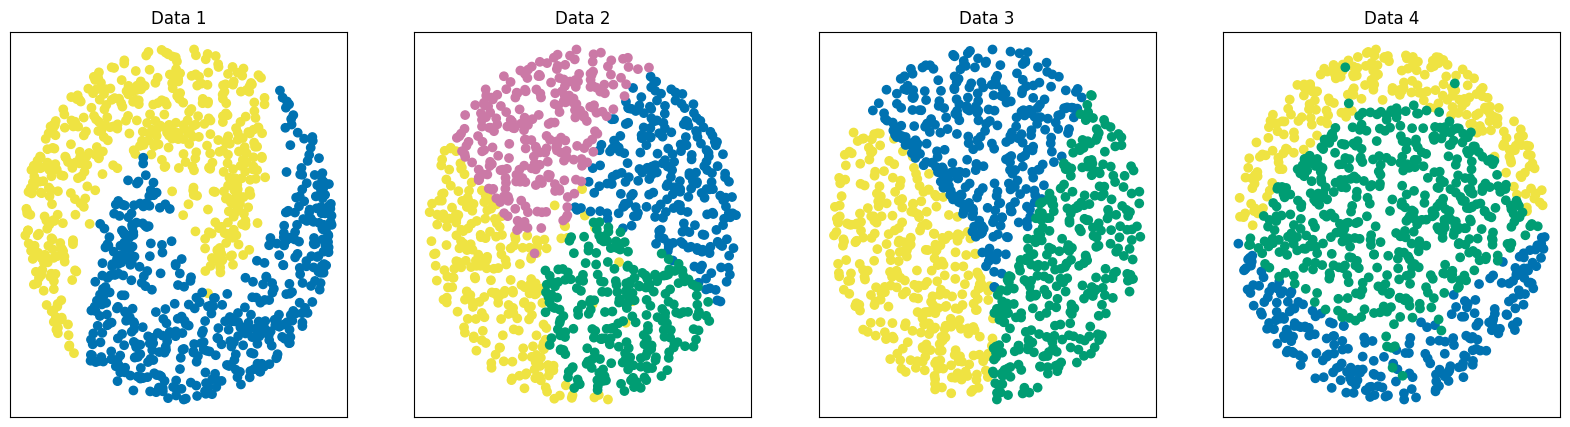

In [15]:
data1_pushed = LAM1.X_pushed
data2_pushed = LAM2.X_pushed
data3_pushed = LAM3.X_pushed
data4_pushed = LAM4.X_pushed

fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for i, data_pushed, data in zip([0, 1, 2, 3], [data1_pushed, data2_pushed, data3_pushed, data4_pushed], [data1, data2, data3, data4]):
    axs[i].scatter(data_pushed[data[1] == 0, 0], data_pushed[data[1] == 0, 1], c=[colour['y'] for _ in range(data_pushed[data[1] == 0].shape[0])])
    axs[i].scatter(data_pushed[data[1] == 1, 0], data_pushed[data[1] == 1, 1], c=[colour['b'] for _ in range(data_pushed[data[1] == 1].shape[0])])
    axs[i].scatter(data_pushed[data[1] == 2, 0], data_pushed[data[1] == 2, 1], c=[colour['g'] for _ in range(data_pushed[data[1] == 2].shape[0])])
    axs[i].scatter(data_pushed[data[1] == 3, 0], data_pushed[data[1] == 3, 1], c=[colour['p'] for _ in range(data_pushed[data[1] == 3].shape[0])])
    axs[i].scatter(data_pushed[data[1] == 4, 0], data_pushed[data[1] == 4, 1], c=[colour['lb'] for _ in range(data_pushed[data[1] == 4].shape[0])])
    axs[i].set_title(f"Data {i+1}")
    axs[i].set_xticks([])
    axs[i].set_yticks([])

plt.show()

In [16]:
def pairwise_distance(x, y, LAM):

    if LAM.save_distance_matrix:
        # y is a subset of LAM.data. Get the indices of the points in y in the LAM.data
        idx_y = [i for i in range(LAM.data.shape[0]) if LAM.data[i] in y]

        _, idx_x, dist_matrix, _ = LAM.check_expansion(x)

        # get entries of dist_matrix corresponding to every pait between x and y
        dist = dist_matrix[np.ix_(idx_x, idx_y)]
        return dist

    else:
        # y is a subset of LAM.data. Get the indices of the points in y in the LAM.data
        idx_y = [i for i in range(LAM.data.shape[0]) if LAM.data[i] in y]

        expanded_graph, idx_x, _, _ = LAM.check_expansion(x)

        # get entries of dist_matrix corresponding to every pait between x and y
        #dist = dist_matrix[np.ix_(idx_x, idx_y)]

        dist_array, _ = LAMINAR.utils.dijkstra.dijkstra(expanded_graph, idx_x, idx_y)

        dist = torch.tensor(np.array([dist_array])[0])
        return dist

In [17]:
def swarm(n_start, data, metric, LAM, n=15):
    # fit a gaussian to the data as floats
    mu = data.mean(axis=0).numpy()
    sigma = data.std(axis=0).numpy()

    # sample n_start points from the gaussian
    swarm = torch.Tensor(np.random.randn(n_start, 2) * sigma + mu)

    # sample a velocity for each start point
    swarm_velocity = torch.Tensor(np.random.randn(n_start, 2))

    # init
    best_dist = 999999
    best_point = None
    local_best_dist = torch.ones(n_start) * 99999
    local_best_point = swarm.clone()

    # arrays for plotting
    #array_of_swarm = []
#
    #array_of_inertia = []
    #array_of_global_best_vectors = []
    #array_of_personal_best_vectors = []
#
    #array_of_swarm_velocity = []
#
    #array_of_global_best_points = []

    
    for _ in range(n):
        # for each point in the swarm, calculate the distance to each point in the data set and sum it up
        #dist = torch.zeros(n_start, data.shape[0])
        #for i in range(n_start):
        #    dist[i] = metric(swarm[i], data)
        #dist = torch.sum(dist, dim=1)

        dist = metric(swarm, data, LAM)  # get the distance from every point in swarm to ever point in data, returning a matrix with shape (n_start, data.shape[0])
        dist = torch.sum(dist**2, dim=1) # KARCHER MEANS and FRECHET MEAN!

        # GLOBAL BEST
        # find the point with lowest distance and the respective distance
        iter_best_point = swarm[torch.argmin(dist)]
        iter_best_dist = torch.min(dist)

        # if iter best is better than best, update best
        if iter_best_dist < best_dist:
            best_dist = iter_best_dist
            best_point = iter_best_point

        # PERSONAL BEST
        # check for every point whether iter peronal best is better than personal best
        for i in range(n_start):
            if dist[i] < local_best_dist[i]:
                local_best_dist[i] = dist[i].clone()
                local_best_point[i] = swarm[i].clone()

        # update velocity
        
        # for each point, get the vector to the best point
        global_best = best_point - swarm
        personal_best = local_best_point - swarm
        inertia = swarm_velocity


        # update velocity
        swarm_velocity = (0.4*inertia + 0.3*global_best + 0.3*personal_best)

        # fill arrays
        #array_of_swarm.append(swarm.clone())
#
        #array_of_inertia.append(inertia.clone())
        #array_of_global_best_vectors.append(global_best.clone())
        #array_of_personal_best_vectors.append(personal_best.clone())
#
        #array_of_swarm_velocity.append(swarm_velocity.clone())
#
        #array_of_global_best_points.append(best_point.clone())

        
        # update swarm
        swarm += swarm_velocity
    #return array_of_swarm, array_of_inertia, array_of_global_best_vectors, array_of_personal_best_vectors, array_of_swarm_velocity, array_of_global_best_points, best_point 
    return best_point   

In [18]:
#new_data = data[data[:, 0]-data[:, 1] > 0]

In [19]:
#new_data.mean(axis=0)

In [20]:
#swarm_points, inertia_vec, global_vec, personal_vec, swarm_vec, best, last = swarm(50, new_data, pairwise_distance, n=25)

In [21]:
#print(last)

In [22]:
'''plt.figure()
for i in range(len(swarm_points)):
    plt.scatter(new_data[:, 0], new_data[:, 1], c='w', edgecolors='k', s=10)

    plt.scatter(swarm_points[i][:, 0], swarm_points[i][:, 1], c='red', s=10)

    if i <= 2:
        # plot vectors
        for j in range(len(swarm_points[i])):
            plt.arrow(swarm_points[i][j][0], swarm_points[i][j][1], 0.4 * inertia_vec[i][j][0], 0.4 * inertia_vec[i][j][1], color='yellow', head_width=0.05)
            plt.arrow(swarm_points[i][j][0], swarm_points[i][j][1], 0.3 * personal_vec[i][j][0], 0.3 * personal_vec[i][j][1], color='green', head_width=0.05)
            plt.arrow(swarm_points[i][j][0], swarm_points[i][j][1], 0.3 * global_vec[i][j][0], 0.3 * global_vec[i][j][1], color='purple', head_width=0.05)
            ä = 0
    for j in range(len(swarm_points[i])):
        plt.arrow(swarm_points[i][j][0], swarm_points[i][j][1], swarm_vec[i][j][0], swarm_vec[i][j][1], color='blue', head_width=0.05)
    
    plt.scatter(best[i][0], best[i][1], c='red', s=100, marker='x')

    plt.xlim(-1.15, 2.15)
    plt.ylim(-2.15, 1.15)

    # clear image
    plt.show()
    plt.pause(0.1)
    plt.clf()'''


"plt.figure()\nfor i in range(len(swarm_points)):\n    plt.scatter(new_data[:, 0], new_data[:, 1], c='w', edgecolors='k', s=10)\n\n    plt.scatter(swarm_points[i][:, 0], swarm_points[i][:, 1], c='red', s=10)\n\n    if i <= 2:\n        # plot vectors\n        for j in range(len(swarm_points[i])):\n            plt.arrow(swarm_points[i][j][0], swarm_points[i][j][1], 0.4 * inertia_vec[i][j][0], 0.4 * inertia_vec[i][j][1], color='yellow', head_width=0.05)\n            plt.arrow(swarm_points[i][j][0], swarm_points[i][j][1], 0.3 * personal_vec[i][j][0], 0.3 * personal_vec[i][j][1], color='green', head_width=0.05)\n            plt.arrow(swarm_points[i][j][0], swarm_points[i][j][1], 0.3 * global_vec[i][j][0], 0.3 * global_vec[i][j][1], color='purple', head_width=0.05)\n            ä = 0\n    for j in range(len(swarm_points[i])):\n        plt.arrow(swarm_points[i][j][0], swarm_points[i][j][1], swarm_vec[i][j][0], swarm_vec[i][j][1], color='blue', head_width=0.05)\n\n    plt.scatter(best[i][0], b

In [23]:
def k_means_LAM(data, k, LAM, epochs=1):
    n = data.shape[0]
    d = data.shape[1]
    # for centroids, take random datapoints from data
    #centroids = torch.rand(k, d)
    centroids = data[np.random.choice(n, k, replace=False)]

    for _ in range(epochs):
        # call query; return idx, the indices of the closest points in increasing order for the centroids, and dists, the distances of the respective point
        idx, dists = LAM.query(centroids)

        for i in range(len(idx)):
            # sort dists[k] according to idx[k], which also sort idx[k]
            sorted_idx = torch.argsort(idx[i])
            #idx[k] = idx[k][sorted_idx]
            dists[i] = dists[i][sorted_idx]

        #idx = idx[:, :n]
        dists = dists[:, :n]

        dists = dists.T
        #idx = idx.T

        # for each point, check which cluster it should be assigned to
        clusters = [[] for _ in range(k)]

        for i in range(n):
            # get argmin of dists[i]
            #print(dists[i])
            cluster = torch.argmin(dists[i]).item()
            #print(cluster)
            clusters[cluster].append(i)

        # update centroids
        for j in range(k):
            if len(clusters[j]) > 0:
                centroids[j] = swarm(50, data[clusters[j]], pairwise_distance, LAM, n=15)
                
    return centroids, clusters

In [24]:
centroids1_lam, labels1_lam = k_means_LAM(data1[0], 2, LAM1, epochs=10)
labels1_lam = transform_labels(labels1_lam)

In [25]:
centroids2_lam, labels2_lam = k_means_LAM(data2[0], 4, LAM2, epochs=10)
labels2_lam = transform_labels(labels2_lam)

In [26]:
centroids3_lam, labels3_lam = k_means_LAM(data3[0], 3, LAM3, epochs=10)
labels3_lam = transform_labels(labels3_lam)

In [27]:
centroids4_lam, labels4_lam = k_means_LAM(data4[0], 3, LAM4, epochs=10)
labels4_lam = transform_labels(labels4_lam)

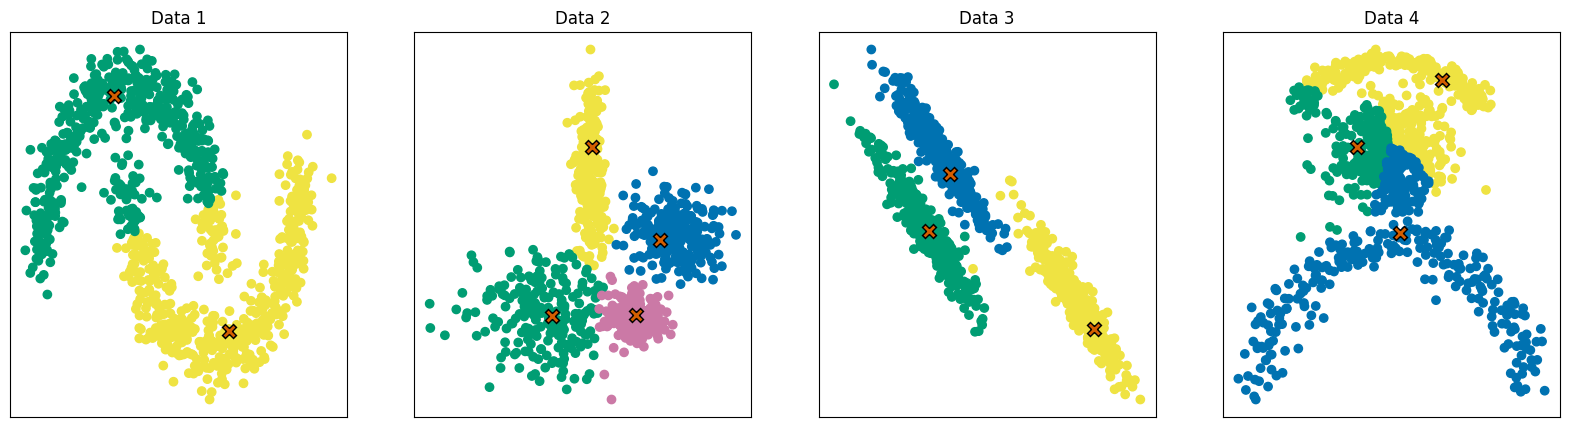

In [28]:
# plot clustering with LAM
fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for i, (data, labels, medoids) in enumerate([(data1[0], labels1_lam, centroids1_lam), (data2[0], labels2_lam, centroids2_lam), (data3[0], labels3_lam, centroids3_lam), (data4[0], labels4_lam, centroids4_lam)]):
    axs[i].scatter(data[labels == 0, 0], data[labels == 0, 1], c=[colour['y'] for _ in range(data[labels == 0].shape[0])])
    axs[i].scatter(data[labels == 1, 0], data[labels == 1, 1], c=[colour['g'] for _ in range(data[labels == 1].shape[0])])
    axs[i].scatter(data[labels == 2, 0], data[labels == 2, 1], c=[colour['b'] for _ in range(data[labels == 2].shape[0])])
    axs[i].scatter(data[labels == 3, 0], data[labels == 3, 1], c=[colour['p'] for _ in range(data[labels == 3].shape[0])])
    axs[i].scatter(data[labels == 4, 0], data[labels == 4, 1], c=[colour['lb'] for _ in range(data[labels == 4].shape[0])])

    axs[i].scatter(medoids[:, 0], medoids[:, 1], c='black', marker='x', s=75, linewidths=4)
    axs[i].scatter(medoids[:, 0], medoids[:, 1], c=[colour['r']], marker='x', s=50, linewidths=2)
    axs[i].set_title(f"Data {i+1}")
    axs[i].set_xticks([])
    axs[i].set_yticks([])